# **Part 1: Supervised Model**

## 1.1 Load and prepare training data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV

df = pd.read_csv("merged_3W_training_data.csv")

df["Week"] = pd.to_datetime(df["Week"])

# Rename the original column to avoid confusion
df = df.rename(columns={"Brent_Return_Lag3W": "Brent_Return_Next3W"})

df.head()

,Week,Port,Tanker_Vessels,Cargo_Vessels,Draft,Avg_SOG,Avg_Length,Unique_Vessels,Brent_Close,Brent_Avg_Close,Brent_Return,WTI_Close,WTI_Avg_Close,WTI_Return,Brent_Close_Lag3W,Brent_Avg_Close_Lag3W,Brent_Return_Next3W,WTI_Close_Lag3W,WTI_Avg_Close_Lag3W,WTI_Return_Lag3W
0,2019-01-06,Anchorage,0,4,9.87,10.25,180.75,4,57.06,55.9733,NaN,47.96,47.1967,NaN,61.64,61.3425,-0.0169,53.69,53.0025,-0.002
1,2019-01-06,Baltimore,19,72,11.46,10.32,208.31,91,57.06,55.9733,NaN,47.96,47.1967,NaN,61.64,61.3425,-0.0169,53.69,53.0025,-0.002
2,2019-01-06,Baton Rouge,0,1,NaN,5.60,24.00,1,57.06,55.9733,NaN,47.96,47.1967,NaN,61.64,61.3425,-0.0169,53.69,53.0025,-0.002
3,2019-01-06,Boston,14,21,11.04,7.52,196.18,35,57.06,55.9733,NaN,47.96,47.1967,NaN,61.64,61.3425,-0.0169,53.69,53.0025,-0.002
4,2019-01-06,Camden (NJ),4,13,12.15,14.11,238.25,17,57.06,55.9733,NaN,47.96,47.1967,NaN,61.64,61.3425,-0.0169,53.69,53.0025,-0.002


In [ ]:
weekly_df = df.groupby("Week").agg({
    "Tanker_Vessels": "sum",
    "Cargo_Vessels": "sum",
    "Unique_Vessels": "sum",
    "Draft": "mean",
    "Avg_SOG": "mean",
    "Avg_Length": "mean",
    "Brent_Return": "first",
    "Brent_Return_Next3W": "first"
}).reset_index()

weekly_df = weekly_df.sort_values("Week")

weekly_df

,Week,Tanker_Vessels,Cargo_Vessels,Unique_Vessels,Draft,Avg_SOG,Avg_Length,Brent_Return,Brent_Return_Next3W
0,2019-01-06,969,1863,2832,11.586552,10.068000,205.128667,NaN,-0.0169
1,2019-01-13,1048,2205,3253,11.404138,10.394138,211.236897,0.0599,0.0037
2,2019-01-20,1057,2259,3316,11.218333,10.847667,205.118667,0.0367,0.0037
3,2019-01-27,1037,2205,3242,11.423333,10.063000,206.914000,-0.0169,0.0668
4,2019-02-03,997,2142,3139,11.196000,10.242333,204.906333,0.0037,0.0131
...,...,...,...,...,...,...,...,...,...
152,2021-12-05,1103,2287,3390,10.436897,9.886552,206.848276,-0.0391,0.0453
153,2021-12-12,1146,2377,3523,10.476552,9.973448,206.457931,0.0754,0.0121
154,2021-12-19,1209,2523,3732,10.573448,10.299655,210.206207,-0.0217,NaN
155,2021-12-26,1214,2276,3490,10.522069,9.784138,204.643448,0.0453,NaN


In [ ]:
feature_cols = [
    "Tanker_Vessels",
    "Cargo_Vessels",
    "Unique_Vessels",
    "Draft",
    "Avg_SOG",
    "Avg_Length"
]

# Remove rows with missing values in X or y
train_df = weekly_df.dropna(subset=feature_cols + ["Brent_Return_Next3W"])

X_train = train_df[feature_cols]
y_train = train_df["Brent_Return_Next3W"]

Baseline model for Comparison

In [ ]:
baseline_df = weekly_df.dropna(subset=["Brent_Return", "Brent_Return_Next3W"])

y_true_baseline = baseline_df["Brent_Return_Next3W"]
y_pred_baseline = baseline_df["Brent_Return"]

baseline_mae = mean_absolute_error(y_true_baseline, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_true_baseline, y_pred_baseline))

print("Baseline: Current Brent_Return predicts Brent_Return_Next3W")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)

Baseline: Current Brent_Return predicts Brent_Return_Next3W
MAE: 0.061094117647058827
RMSE: 0.1052838870043517


Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr_train = lr.predict(X_train)

lr_mae_train = mean_absolute_error(y_train, y_pred_lr_train)
lr_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))

print("Linear Regression Training")
print("MAE:", lr_mae_train)
print("RMSE:", lr_rmse_train)

Linear Regression Training
MAE: 0.042679555434935436
RMSE: 0.06683469859511397


SVR

In [ ]:
svr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf", C=1.0, epsilon=0.05))
])

svr.fit(X_train, y_train)

y_pred_svr_train = svr.predict(X_train)

svr_mae_train = mean_absolute_error(y_train, y_pred_svr_train)
svr_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_svr_train))

print("SVR Training")
print("MAE:", svr_mae_train)
print("RMSE:", svr_rmse_train)

SVR Training
MAE: 0.03860158934801789
RMSE: 0.05769152145678799


Random Forest

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42)

rf.fit(X_train, y_train)
y_pred_rf_train = rf.predict(X_train)
rf_mae_train = mean_absolute_error(y_train, y_pred_rf_train)
rf_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))

print("Random Forest Training")
print("MAE:", rf_mae_train)
print("RMSE:", rf_rmse_train)

Random Forest Training
MAE: 0.017724909090909086
RMSE: 0.026865315591988532


Gradient Boosting

In [ ]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb_train = gb.predict(X_train)

gb_mae_train = mean_absolute_error(y_train, y_pred_gb_train)
gb_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_gb_train))

print("Gradient Boosting Training")
print("MAE:", gb_mae_train)
print("RMSE:", gb_rmse_train)

Gradient Boosting Training
MAE: 0.01593893727727106
RMSE: 0.02176637148760978


Compare training results

In [ ]:
initial_results_train = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "SVR",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        lr_mae_train,
        svr_mae_train,
        rf_mae_train,
        gb_mae_train
    ],
    "RMSE": [
        baseline_rmse,
        lr_rmse_train,
        svr_rmse_train,
        rf_rmse_train,
        gb_rmse_train
    ]
})

initial_results_train

,Model,MAE,RMSE
0,Baseline,0.061094,0.105284
1,Linear Regression,0.042680,0.066835
2,SVR,0.038602,0.057692
3,Random Forest,0.017725,0.026865
4,Gradient Boosting,0.015939,0.021766


All supervised learning models perform better than the baseline on the training set. Gradient Boosting has the lowest MAE and RMSE, followed by Random Forest. This suggests that tree-based models may fit the relationship between shipping activity and future Brent returns better than Linear Regression.

However, because these are training results, the low errors from Random Forest and Gradient Boosting may indicate overfitting. These models should be evaluated on a test set before making a final conclusion.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": gb.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
5,Avg_Length,0.266062
3,Draft,0.188507
2,Unique_Vessels,0.182825
4,Avg_SOG,0.143466
1,Cargo_Vessels,0.115352
0,Tanker_Vessels,0.103789


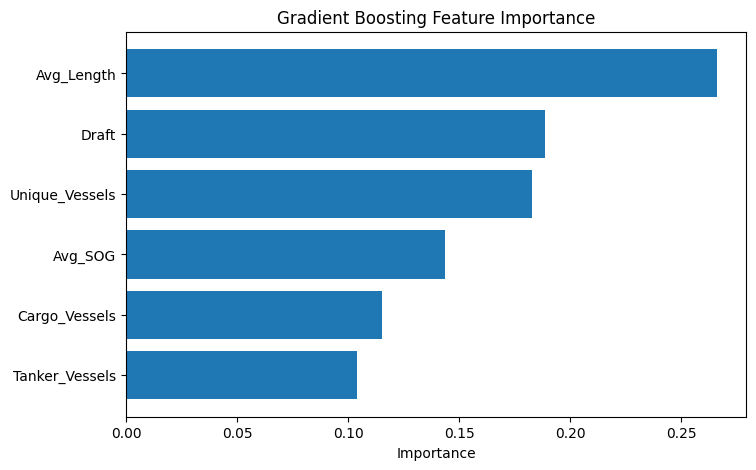

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Gradient Boosting Feature Importance")
plt.show()

The feature importance plot from the Gradient Boosting model shows that Avg_Length, Draft, and Unique_Vessels are the most important predictors in the training data. This suggests that vessel size and overall traffic activity may contain more predictive information than tanker count alone. However, because this importance is based on the training set, it should be interpreted carefully and validated using test-set performance.

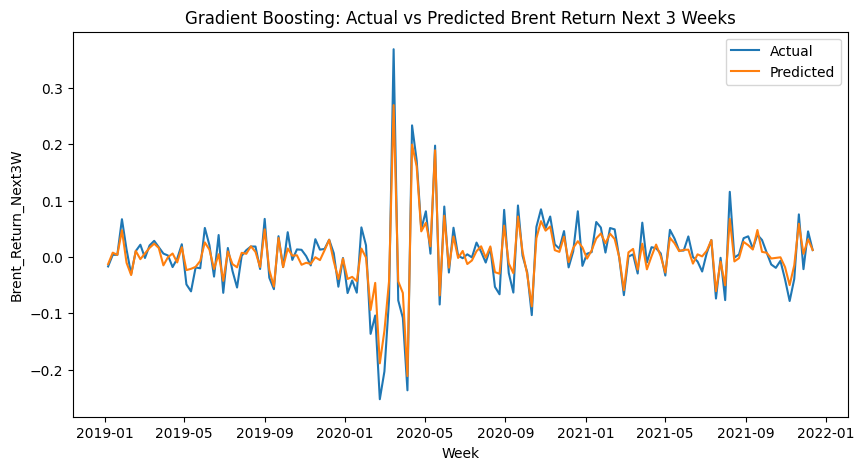

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_df["Week"], y_train, label="Actual")
plt.plot(train_df["Week"], y_pred_gb_train, label="Predicted")
plt.xlabel("Week")
plt.ylabel("Brent_Return_Next3W")
plt.title("Gradient Boosting: Actual vs Predicted Brent Return Next 3 Weeks")
plt.legend()
plt.show()

## Cross-validation comparison

To compare the supervised model families, I used TimeSeriesSplit cross-validation on the training data. This was necessary because the data is time ordered, so random cross-validation could create temporal leakage by allowing future observations to influence earlier validation folds.

I reported the mean and standard deviation of MAE and RMSE across folds. MAE measures the average absolute prediction error, while RMSE gives larger penalty to large errors. Both metrics are appropriate because the target is a continuous future Brent return.

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

models_cv = {
    "Linear Regression": LinearRegression(),
    # Standardize features before fitting SVR because SVR is sensitive to feature scale
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=1.0, epsilon=0.05))]),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42)}

cv_results = []

for name, model in models_cv.items():
    mae_scores = -cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring="neg_mean_absolute_error")

    rmse_scores = -cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring="neg_root_mean_squared_error")

    cv_results.append({
        "Model": name,
        "CV MAE Mean": mae_scores.mean(),
        "CV MAE Std": mae_scores.std(),
        "CV RMSE Mean": rmse_scores.mean(),
        "CV RMSE Std": rmse_scores.std()})

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,CV MAE Mean,CV MAE Std,CV RMSE Mean,CV RMSE Std
0,Linear Regression,0.059882,0.024683,0.074089,0.035328
1,SVR,0.052944,0.029823,0.067079,0.039920
2,Random Forest,0.052351,0.028061,0.066977,0.039327
3,Gradient Boosting,0.054720,0.028192,0.070208,0.038822


The cross-validation results show that Random Forest and SVR had the lowest average MAE, with very similar performance. Linear Regression had the highest CV MAE, suggesting that a simple linear relationship may not capture the full relationship between maritime activity and future Brent returns. Default Gradient Boosting did not outperform Random Forest or SVR during cross-validation, so I performed additional hyperparameter tuning for Gradient Boosting using GridSearchCV.

Tune SVR

In [ ]:
svr_param_grid = {
    "model__C": [0.1, 1, 10],
    "model__epsilon": [0.01, 0.05, 0.1],
    "model__gamma": ["scale", "auto"]
}

svr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf"))])

svr_grid = GridSearchCV(
    svr_pipe,
    svr_param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1)

svr_grid.fit(X_train, y_train)

print("Best SVR parameters:", svr_grid.best_params_)
print("Best SVR CV MAE:", -svr_grid.best_score_)

best_svr = svr_grid.best_estimator_

Best SVR parameters: {'model__C': 0.1, 'model__epsilon': 0.05, 'model__gamma': 'scale'}
Best SVR CV MAE: 0.04726514900830198


Tune Random Forest

In [ ]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 5, None],
    "min_samples_leaf": [3, 5, 10]}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1)

rf_grid.fit(X_train, y_train)

print("Best RF parameters:", rf_grid.best_params_)
print("Best RF CV MAE:", -rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

Best RF parameters: {'max_depth': 2, 'min_samples_leaf': 10, 'n_estimators': 200}
Best RF CV MAE: 0.04805552871418646


## Tuned Gradient boosting model

In [ ]:
gb_param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.03, 0.05],
    "max_depth": [1, 2],
    "min_samples_leaf": [5, 10]}

# Tune Gradient Boosting using TimeSeriesSplit and minimize cross-validation MAE
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1)

gb_grid.fit(X_train, y_train)

print("Best GB parameters:", gb_grid.best_params_)
print("Best GB CV MAE:", -gb_grid.best_score_)

best_gb = gb_grid.best_estimator_

Best GB parameters: {'learning_rate': 0.03, 'max_depth': 1, 'min_samples_leaf': 10, 'n_estimators': 50}
Best GB CV MAE: 0.04739799656746289


In [ ]:
tuned_cv_results = pd.DataFrame({
    "Model": [
        "Tuned SVR",
        "Tuned Random Forest",
        "Tuned Gradient Boosting"],
    "Best CV MAE": [
        -svr_grid.best_score_,
        -rf_grid.best_score_,
        -gb_grid.best_score_],
    "Best Parameters": [
        svr_grid.best_params_,
        rf_grid.best_params_,
        gb_grid.best_params_]})

tuned_cv_results

,Model,Best CV MAE,Best Parameters
0,Tuned SVR,0.047265,"{'model__C': 0.1, 'model__epsilon': 0.05, 'mod..."
1,Tuned Random Forest,0.048056,"{'max_depth': 2, 'min_samples_leaf': 10, 'n_es..."
2,Tuned Gradient Boosting,0.047398,"{'learning_rate': 0.03, 'max_depth': 1, 'min_s..."


Based on cross-validation, tuned SVR had the lowest average MAE, while tuned Gradient Boosting performed very similarly. Therefore, both tuned SVR and tuned Gradient Boosting were evaluated on the held-out test set.

## 1.2 Load and prepare testing data

In [ ]:
test_raw = pd.read_csv("merged_3W_testing_data.csv")

test_raw["Week"] = pd.to_datetime(test_raw["Week"])

# Rename target variable
test_raw = test_raw.rename(columns={"Brent_Return_Lag3W": "Brent_Return_Next3W"})
test_weekly_df = test_raw.groupby("Week").agg({
    "Tanker_Vessels": "sum",
    "Cargo_Vessels": "sum",
    "Unique_Vessels": "sum",
    "Draft": "mean",
    "Avg_SOG": "mean",
    "Avg_Length": "mean",
    "Brent_Return": "first",
    "Brent_Return_Next3W": "first"
}).reset_index()

test_weekly_df = test_weekly_df.sort_values("Week")

test_weekly_df.head()

,Week,Tanker_Vessels,Cargo_Vessels,Unique_Vessels,Draft,Avg_SOG,Avg_Length,Brent_Return,Brent_Return_Next3W
0,2022-01-09,1138,2399,3537,10.554828,9.333793,207.547586,NaN,0.0243
1,2022-01-16,1145,2449,3594,10.659310,10.070000,209.001034,0.0527,0.0360
2,2022-01-23,1133,2537,3670,10.599310,9.814483,206.995862,0.0213,0.0125
3,2022-01-30,1151,2540,3691,10.620345,9.741034,208.273448,0.0243,-0.0095
4,2022-02-06,1109,2516,3625,10.679310,9.822759,209.451724,0.0360,0.0469


In [ ]:
test_df = test_weekly_df.dropna(
    subset=feature_cols + ["Brent_Return", "Brent_Return_Next3W"]
).reset_index(drop=True)

X_test = test_df[feature_cols]
y_test = test_df["Brent_Return_Next3W"]

Baseline test evaluation

In [ ]:
baseline_test_df = test_weekly_df.dropna(subset=["Brent_Return", "Brent_Return_Next3W"])

y_true_baseline_test = baseline_test_df["Brent_Return_Next3W"]
y_pred_baseline_test = test_df["Brent_Return"]

baseline_mae_test = mean_absolute_error(y_test, y_pred_baseline_test)
baseline_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_baseline_test))

print("Baseline Test")
print("MAE:", baseline_mae_test)
print("RMSE:", baseline_rmse_test)

Baseline Test
MAE: 0.054158585858585864
RMSE: 0.07124651116746247


In [ ]:
# Predict on test set using the updated models
y_pred_lr_test = lr.predict(X_test)
y_pred_best_svr_test = svr_grid.best_estimator_.predict(X_test)
y_pred_best_rf_test = rf_grid.best_estimator_.predict(X_test)
y_pred_best_gb_test = gb_grid.best_estimator_.predict(X_test)

# Linear Regression
lr_mae_test = mean_absolute_error(y_test, y_pred_lr_test)
lr_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))

# Tuned SVR
best_svr_mae_test = mean_absolute_error(y_test, y_pred_best_svr_test)
best_svr_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_best_svr_test))

# Tuned Random Forest
best_rf_mae_test = mean_absolute_error(y_test, y_pred_best_rf_test)
best_rf_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_best_rf_test))

# Tuned Gradient Boosting
best_gb_mae_test = mean_absolute_error(y_test, y_pred_best_gb_test)
best_gb_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_best_gb_test))

In [ ]:
results_test = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Tuned SVR",
        "Tuned Random Forest",
        "Tuned Gradient Boosting"],
    "Test MAE": [
        baseline_mae_test,
        lr_mae_test,
        best_svr_mae_test,
        best_rf_mae_test,
        best_gb_mae_test],
    "Test RMSE": [
        baseline_rmse_test,
        lr_rmse_test,
        best_svr_rmse_test,
        best_rf_rmse_test,
        best_gb_rmse_test]})

results_test

,Model,Test MAE,Test RMSE
0,Baseline,0.054159,0.071247
1,Linear Regression,0.043213,0.056458
2,Tuned SVR,0.044550,0.059008
3,Tuned Random Forest,0.041661,0.055646
4,Tuned Gradient Boosting,0.041411,0.054896


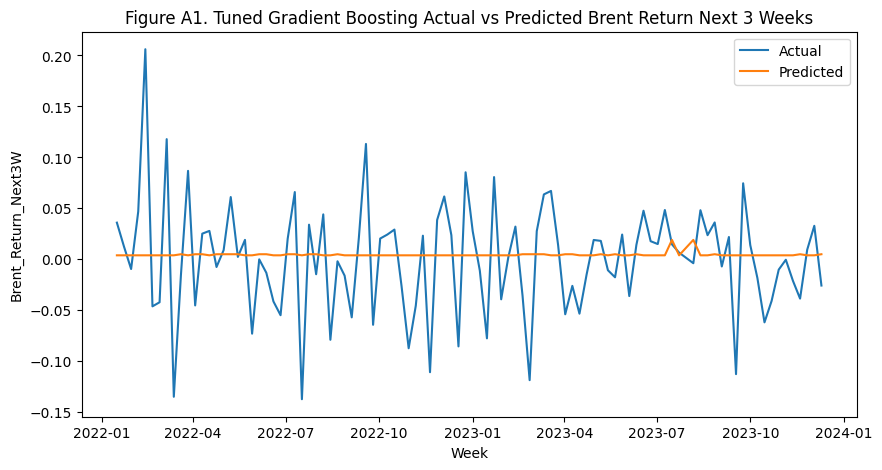

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(test_df["Week"], y_test, label="Actual")
plt.plot(test_df["Week"], y_pred_best_gb_test, label="Predicted")
plt.xlabel("Week")
plt.ylabel("Brent_Return_Next3W")
plt.title("Figure A1. Tuned Gradient Boosting Actual vs Predicted Brent Return Next 3 Weeks")
plt.legend()
plt.show()

Although the tuned Gradient Boosting model achieved the lowest test MAE and RMSE among the evaluated models, the actual-versus-predicted plot shows that its predictions are very conservative and remain close to zero. The model reduces average prediction error, but it does not fully capture large positive or negative movements in future Brent returns. This suggests that maritime activity features provide some limited predictive signal, but they are not sufficient to strongly predict short-term Brent return fluctuations.

# Part 2: Investigating Model Drive

## 2.1 Tuned Gradient Boosting Feature Importance

In this section, we examine the feature importance results from the tuned Gradient Boosting model. The purpose is to understand which maritime variables were used most by the model when predicting future Brent crude oil returns.

However, feature importance should be interpreted carefully. It explains how the model used the variables internally, but it does not prove that these variables directly or strongly predict future oil returns.

In [ ]:
feature_cols = [
    "Tanker_Vessels",
    "Cargo_Vessels",
    "Unique_Vessels",
    "Draft",
    "Avg_SOG",
    "Avg_Length"]


feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": best_gb.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
3,Draft,0.534041
1,Cargo_Vessels,0.438316
5,Avg_Length,0.027643
0,Tanker_Vessels,0.000000
2,Unique_Vessels,0.000000
4,Avg_SOG,0.000000


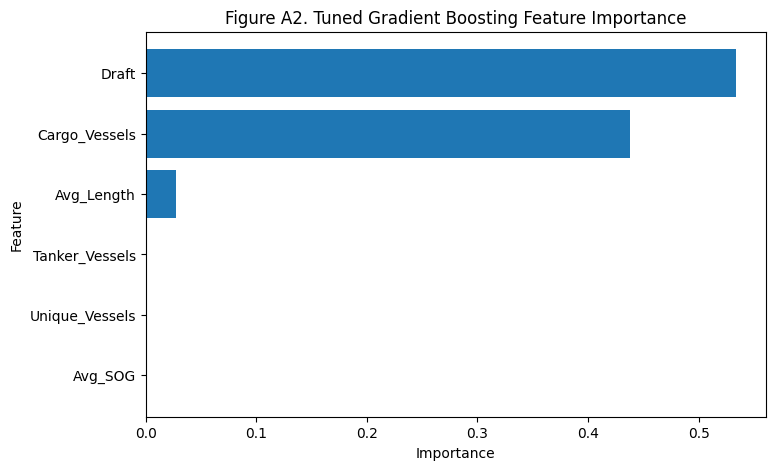

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"])

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Figure A2. Tuned Gradient Boosting Feature Importance")

plt.show()

### Interpretation

The feature importance results suggest that, within the tuned Gradient Boosting model, the model relied mainly on a small subset of variables. Draft had the highest feature importance, followed by Cargo_Vessels. The remaining maritime variables, including Avg_Length, Tanker_Vessels, Unique_Vessels, and Avg_SOG, received much smaller or almost no importance in this model.

However, these results should be interpreted cautiously. Feature importance describes how the Gradient Boosting model used variables internally to reduce prediction error. It does not prove that Draft or Cargo_Vessels directly or strongly predict future Brent crude oil returns. Since the overall predictive performance of the model was still limited, the feature importance results should be treated as model-level evidence rather than strong evidence of a stable market relationship.

### Key Finding

The tuned Gradient Boosting model relied mainly on Draft and Cargo_Vessels. This suggests that vessel loading and cargo activity may provide useful information within the model, but the overall predictive signal remains limited.

## 2.2 Feature Reduction Analysis

To further examine the feature importance results, we tested whether a simpler Gradient Boosting model using only the most important maritime variables could achieve similar prediction performance. The reduced model used only Draft and Cargo_Vessels as input features.

The objective of this analysis is to evaluate whether the model can be simplified without losing much predictive performance.

In [ ]:
important_maritime_features = [
"Draft",
"Cargo_Vessels"]

important_train = train_df.dropna(
subset=important_maritime_features + ["Brent_Return_Next3W"])

important_test = test_df.dropna(
subset=important_maritime_features + ["Brent_Return_Next3W"])

X_train_important = important_train[important_maritime_features]
y_train_important = important_train["Brent_Return_Next3W"]

X_test_important = important_test[important_maritime_features]
y_test_important = important_test["Brent_Return_Next3W"]

# Train the reduced model using the best Gradient Boosting hyperparameters
important_gb = GradientBoostingRegressor(
learning_rate=0.03,
max_depth=1,
min_samples_leaf=10,
n_estimators=50,
random_state=42)

important_gb.fit(X_train_important, y_train_important)

y_pred_important = important_gb.predict(X_test_important)

important_mae = mean_absolute_error(y_test_important, y_pred_important)
important_rmse = np.sqrt(mean_squared_error(y_test_important, y_pred_important))

print("Draft + Cargo_Vessels Model")
print("MAE:", important_mae)
print("RMSE:", important_rmse)


NameError: name 'train_df' is not defined

In [ ]:
feature_reduction_results = pd.DataFrame({
    "Model": [
        "Full Maritime Feature Set",
        "Draft + Cargo_Vessels"
    ],
    "MAE": [
        best_gb_mae_test,
        important_mae
    ],
    "RMSE": [
        best_gb_rmse_test,
        important_rmse
    ]})

feature_reduction_results

,Model,MAE,RMSE
0,Full Maritime Feature Set,0.041411,0.054896
1,Draft + Cargo_Vessels,0.041387,0.054924


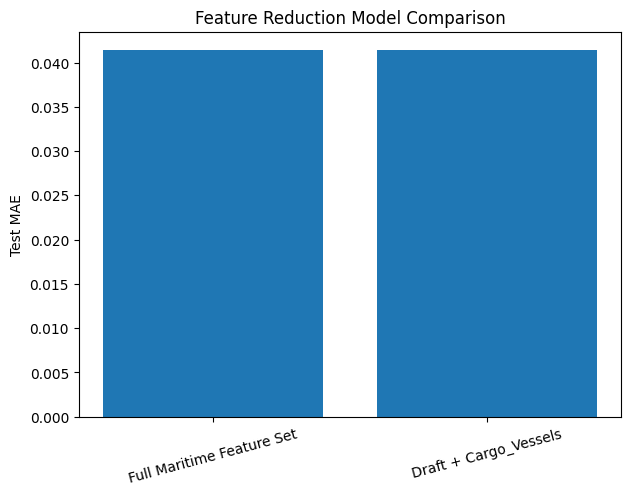

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    feature_reduction_results["Model"],
    feature_reduction_results["MAE"])

plt.ylabel("Test MAE")
plt.title("Feature Reduction Model Comparison")
plt.xticks(rotation=15)

plt.show()

### Interpretation

The reduced model using only Draft and Cargo_Vessels performed almost the same as the full maritime feature model. The full feature model had a test MAE of approximately 0.04120 and a test RMSE of approximately 0.05466. The reduced Draft + Cargo_Vessels model had a test MAE of approximately 0.04117 and a test RMSE of approximately 0.05468.

This result suggests that the other maritime variables added limited additional predictive value in this model setting. However, this should not be interpreted as proof that Draft and Cargo_Vessels are strong standalone predictors. Instead, the result mainly shows that the model can be simplified without losing much predictive performance.

### Key Finding

The reduced model using only Draft and Cargo_Vessels achieved nearly the same test performance as the full maritime feature model. This supports the idea that most of the information used by the tuned Gradient Boosting model was concentrated in these two variables. However, because the model’s overall predictive performance remained modest, this result should be interpreted as model simplification rather than strong evidence of a direct relationship between maritime activity and future Brent returns.

## 6.3 Investigating Draft Behavior

The previous analyses identified Draft as the most important as the most important maritime predictor within the tuned Gradient Boosting model. However, feature importance alone does not explain how Draft relates to future Brent crude returns.

To better understand this relationship, additional analyses were performed to examine the distribution of Draft values, the relationship between Draft and future returns, and whether different Draft environments are associated with different return patterns.

The objective is to determine whether Draft contains a meaningful predictive signal or whether its importance may be driven by broader underlying effects.

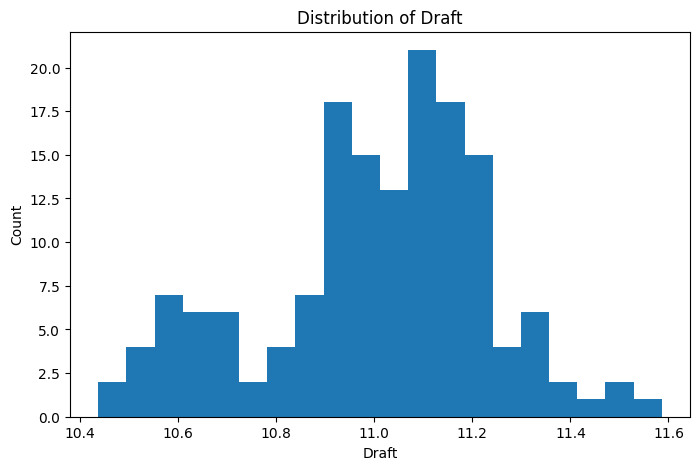

count    154.000000
mean      11.001324
std        0.233407
min       10.436897
25%       10.898506
50%       11.032071
75%       11.151083
max       11.586552
Name: Draft, dtype: float64


In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_df["Draft"],
    bins=20)

plt.xlabel("Draft")
plt.ylabel("Count")
plt.title("Distribution of Draft")

plt.show()

print(train_df["Draft"].describe())

The distribution of Draft values is relatively concentrated, with most observations falling between approximately 10.8 and 11.2 meters. The average Draft value is approximately 11.0 meters, indicating that large week to week changes are relatively uncommon.

Because the range of Draft values is fairly narrow, any predictive information contained within Draft is likely driven subtle changes rather than extreme fluctuations.

## 2.4 Draft Correlation and Nonlinear Pattern

In [ ]:
train_df[
    ["Draft", "Brent_Return_Next3W"]].corr()

,Draft,Brent_Return_Next3W
Draft,1.000000,-0.042791
Brent_Return_Next3W,-0.042791,1.000000


The correlation between Draft and future Brent returns is approximately -0.043. This is very weak and suggests that there is little evidence of a simple linear relationship between Draft and Brent_Return_Next3W.

This result is important because it limits how strongly we can interpret the feature importance result. Draft may help the Gradient Boosting model, but Draft alone does not appear to directly predict future Brent returns through a simple linear relationship.

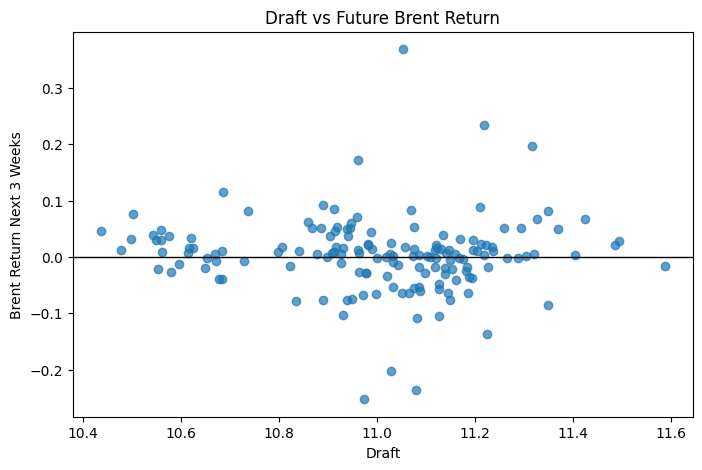

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    train_df["Draft"],
    train_df["Brent_Return_Next3W"],
    alpha=0.7)

plt.axhline(
    y=0,
    color="black",
    linewidth=1)

plt.xlabel("Draft")
plt.ylabel("Brent Return Next 3 Weeks")
plt.title("Draft vs Future Brent Return")

plt.show()

This suggests that Draft does not directly predict future Brent returns through a simple increase-or-decrease pattern. If Draft contains useful information, the relationship is more likely nonlinear, time-dependent, or related to broader maritime or economic regimes.

## 2.5 Temporal effects: Is Draft Acting Like Time?

Because Draft was the most important maritime feature in the tuned Gradient Boosting model, I checked whether Draft was also strongly related to time. If Draft changes systematically over time, then part of its model importance may reflect broader time-dependent maritime or economic regimes rather than a direct ship-to-oil return relationship.

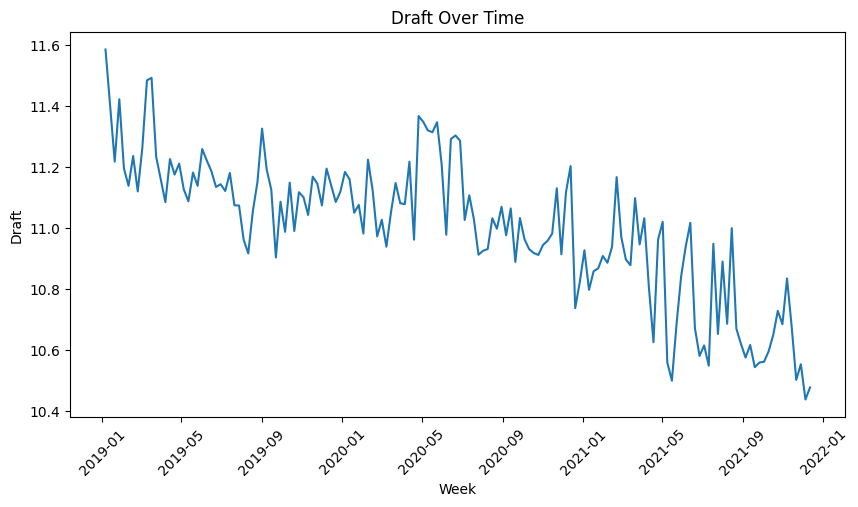

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_df["Week"],
    train_df["Draft"])

plt.xlabel("Week")
plt.ylabel("Draft")
plt.title("Draft Over Time")
plt.xticks(rotation=45)

plt.show()

In [ ]:
train_df = train_df.copy()
train_df["Time_Index"] = range(len(train_df))

draft_time_corr = train_df[
    ["Time_Index", "Draft"]].corr()

draft_time_corr

,Time_Index,Draft
Time_Index,1.000000,-0.788764
Draft,-0.788764,1.000000


Draft shows a clear downward trend over the training period. The correlation between Draft and the time index is approximately -0.79, which indicates that Draft is strongly related to time.

This suggests that Draft may partly capture broader time-dependent changes in the maritime system. Therefore, its high feature importance may not only reflect vessel loading behavior, but may also overlap with economic or maritime regime changes over time.

### Key Finding

Draft is strongly related to time, so its importance in the Gradient Boosting model should be interpreted cautiously. It may act partly as a proxy for time-dependent regime changes.

## 2.6 Time Only vs Draft Only Model

In [ ]:
test_df = test_df.copy()
test_df["Time_Index"] = range(len(test_df))

In [ ]:
# Draft only model
X_train_draft = train_df[["Draft"]]
y_train_draft = train_df["Brent_Return_Next3W"]

X_test_draft = test_df[["Draft"]]
y_test_draft = test_df["Brent_Return_Next3W"]

draft_only_gb = GradientBoostingRegressor(
    learning_rate=0.03,
    max_depth=1,
    min_samples_leaf=10,
    n_estimators=50,
    random_state=42)

draft_only_gb.fit(X_train_draft, y_train_draft)

y_pred_draft_only = draft_only_gb.predict(X_test_draft)

draft_only_mae = mean_absolute_error(y_test_draft, y_pred_draft_only)
draft_only_rmse = np.sqrt(mean_squared_error(y_test_draft, y_pred_draft_only))

In [ ]:
# Time only model
X_train_time = train_df[["Time_Index"]]
y_train_time = train_df["Brent_Return_Next3W"]

X_test_time = test_df[["Time_Index"]]
y_test_time = test_df["Brent_Return_Next3W"]

time_only_gb = GradientBoostingRegressor(
    learning_rate=0.03,
    max_depth=1,
    min_samples_leaf=10,
    n_estimators=50,
    random_state=42)

time_only_gb.fit(X_train_time, y_train_time)

y_pred_time_only = time_only_gb.predict(X_test_time)

time_only_mae = mean_absolute_error(y_test_time, y_pred_time_only)
time_only_rmse = np.sqrt(mean_squared_error(y_test_time, y_pred_time_only))

In [ ]:
# Time + Draft model
X_train_time_draft = train_df[["Time_Index", "Draft"]]
y_train_time_draft = train_df["Brent_Return_Next3W"]

X_test_time_draft = test_df[["Time_Index", "Draft"]]
y_test_time_draft = test_df["Brent_Return_Next3W"]

time_draft_gb = GradientBoostingRegressor(
    learning_rate=0.03,
    max_depth=1,
    min_samples_leaf=10,
    n_estimators=50,
    random_state=42)

time_draft_gb.fit(X_train_time_draft, y_train_time_draft)

y_pred_time_draft = time_draft_gb.predict(X_test_time_draft)

time_draft_mae = mean_absolute_error(y_test_time_draft, y_pred_time_draft)
time_draft_rmse = np.sqrt(mean_squared_error(y_test_time_draft, y_pred_time_draft))

In [ ]:
time_draft_results = pd.DataFrame({
    "Model": [
        "Draft Only",
        "Time Only",
        "Time + Draft"],
    "MAE": [
        draft_only_mae,
        time_only_mae,
        time_draft_mae],
    "RMSE": [
        draft_only_rmse,
        time_only_rmse,
        time_draft_rmse]})

time_draft_results

,Model,MAE,RMSE
0,Draft Only,0.041273,0.055357
1,Time Only,0.041515,0.055128
2,Time + Draft,0.041417,0.054921


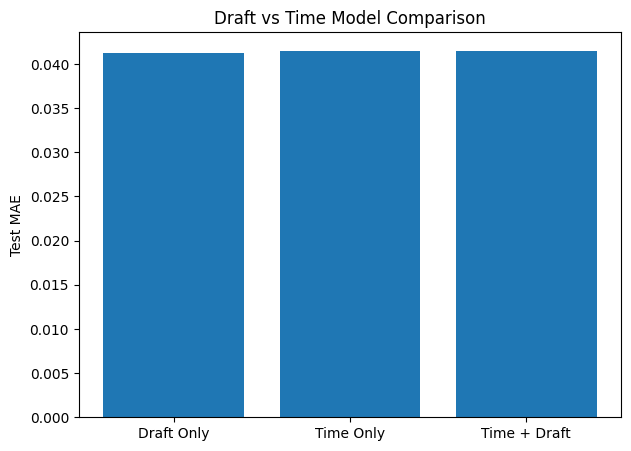

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    time_draft_results["Model"],
    time_draft_results["MAE"])

plt.ylabel("Test MAE")
plt.title("Draft vs Time Model Comparison")
plt.xticks(rotation=0)

plt.show()

The Draft Only, Time Only, and Time + Draft models produced very similar MAE values. This means that adding Draft to the Time Only model did not clearly improve prediction performance in this simplified experiment.

This result does not prove that Draft is only a time proxy or that Draft has no useful information. However, it suggests that Draft does not provide a large amount of additional predictive value beyond the time trend in this model setting.

### Key Finding

In this simplified comparison, Draft did not clearly improve performance beyond the Time Only model. This is consistent with the possibility that Draft partly reflects broader time-related maritime or economic changes, rather than acting as a fully independent predictor of future Brent returns.

## 2.7 Pre-COVID vs Post-COVID Draft Relationship

In [ ]:
pre_covid = train_df[train_df["Week"] < "2020-03-01"]
post_covid = train_df[train_df["Week"] > "2020-06-01"]

pre_corr = pre_covid[
    ["Draft", "Brent_Return_Next3W"]].corr().iloc[0, 1]

post_corr = post_covid[
    ["Draft", "Brent_Return_Next3W"]].corr().iloc[0, 1]

covid_corr_results = pd.DataFrame({
    "Period": [
        "Pre-COVID",
        "Post-COVID" ],
    "Draft_Return_Correlation": [
        pre_corr,
        post_corr]})

covid_corr_results

,Period,Draft_Return_Correlation
0,Pre-COVID,0.186595
1,Post-COVID,-0.165969


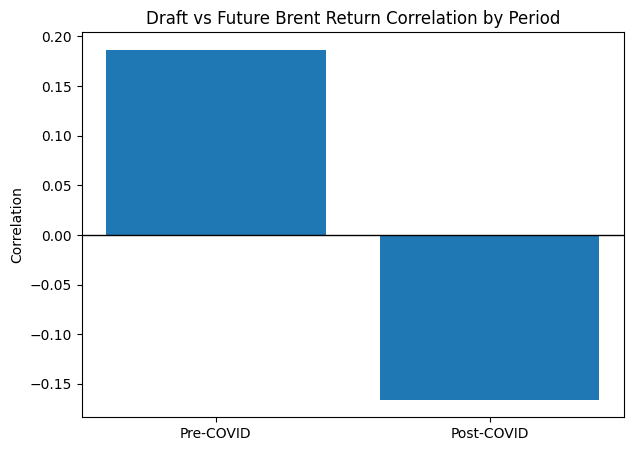

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    covid_corr_results["Period"],
    covid_corr_results["Draft_Return_Correlation"])

plt.axhline(
    y=0,
    color="black",
    linewidth=1)

plt.ylabel("Correlation")
plt.title("Draft vs Future Brent Return Correlation by Period")

plt.show()

The relationship between Draft and future Brent returns changed across periods. Before COVID, the correlation was positive. After the early COVID shock period, the correlation became negative.

Although both correlations are still modest, the change in direction suggests that Draft is not a stable standalone predictor of future Brent returns. Instead, Draft may reflect broader maritime or economic regimes that changed over time.

### Key Finding

Draft’s relationship with future Brent returns appears to change across time periods. This supports the interpretation that Draft may act as a proxy for regime changes rather than a direct and stable predictor.

## 2.8 Failure analysis

In [ ]:
# Failure analysis for the tuned Gradient Boosting model

failure_df = test_df.copy()

failure_df["Actual"] = y_test.values
failure_df["Predicted"] = y_pred_best_gb_test
failure_df["Error"] = failure_df["Actual"] - failure_df["Predicted"]
failure_df["Abs_Error"] = failure_df["Error"].abs()

top_failures = failure_df.sort_values(by="Abs_Error", ascending=False).head(3)

top_failures[[
    "Week",
    "Actual",
    "Predicted",
    "Error",
    "Abs_Error",
    "Tanker_Vessels",
    "Cargo_Vessels",
    "Unique_Vessels",
    "Draft",
    "Avg_SOG",
    "Avg_Length"]]

,Week,Actual,Predicted,Error,Abs_Error,Tanker_Vessels,Cargo_Vessels,Unique_Vessels,Draft,Avg_SOG,Avg_Length
4,2022-02-13,0.2061,0.003949,0.202151,0.202151,1135,2496,3631,10.957500,10.081786,217.417143
26,2022-07-17,-0.1372,0.003949,-0.141149,0.141149,1305,2264,3569,10.470690,9.927241,206.257241
8,2022-03-13,-0.1348,0.003949,-0.138749,0.138749,1204,2543,3747,10.613793,9.746897,207.568621


## Final Updated Interpretation

The supervised analysis provides limited evidence that maritime activity may contain market-related information for predicting future Brent crude returns. The tuned Gradient Boosting model improved over the baseline, and its feature importance results showed that the model relied mainly on Draft and Cargo_Vessels.

However, additional analysis shows that Draft should be interpreted cautiously. Draft has a very weak direct correlation with future Brent returns, and the scatter plot does not show a clear linear relationship. Draft is also strongly related to time, and its relationship with future Brent returns changes before and after the early COVID period.

Overall, these results suggest that Draft may act as a proxy for broader maritime or economic regime changes rather than serving as a direct and stable predictor of future oil returns. The results support the idea that maritime activity contains limited and complex predictive information, but shipping activity alone is not sufficient to strongly predict short-term Brent return movements.